This notebook is used to get the Experiment results for the dropclass-publication

# Prerequisites

In [1]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('darkgrid')

In [2]:
# import new main notebook
df_main = pd.read_excel('../data/df_main_edited.xlsx')
display(df_main.head())
df_main.info()

,test,one_drop,splashing,breaking_up,net_impact,rebound,voltage,long_impulse_duration,height,inclination,...,Re,We,We_Re,particle_droplet_diameter_ratio,particle_diameter_cat,breaking_up_receding,splashing_semi,rebound_total,rebound_true,jet_ejection
0,3,1,1,0,0,0,105.0,10,0.8,0,...,1492.516020,1492.302356,240.108847,0.013301,small,0,0,0,0,0
1,4,1,1,0,0,0,105.0,10,0.8,0,...,1492.516020,1492.302356,240.108847,0.013301,small,0,0,0,0,0
2,5,1,1,0,0,0,105.0,10,0.8,0,...,1492.516020,1492.302356,240.108847,0.013301,small,0,0,0,0,0
3,7,0,1,0,0,0,105.0,10,0.8,0,...,1435.111557,1434.906112,233.148786,0.013833,small,0,0,0,0,0
4,8,0,1,0,0,0,105.0,10,0.8,0,...,1435.111557,1434.906112,233.148786,0.013833,small,0,0,0,0,0


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 372 entries, 0 to 371
Data columns (total 33 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   test                             372 non-null    int64  
 1   one_drop                         372 non-null    int64  
 2   splashing                        372 non-null    int64  
 3   breaking_up                      372 non-null    int64  
 4   net_impact                       372 non-null    int64  
 5   rebound                          372 non-null    int64  
 6   voltage                          372 non-null    float64
 7   long_impulse_duration            372 non-null    int64  
 8   height                           372 non-null    float64
 9   inclination                      372 non-null    int64  
 10  droplet_diameter                 372 non-null    float64
 11  liquid_density                   372 non-null    int64  
 12  surface_tension       

Let us remind **new classes definition**:
- **breaking_up_receding**. Include only tests with *'Number of detached small droplets during **Receding or Rim merging**' > 0*
- **splashing_semi**. Include only tests with *a few count of 'Number of detached small droplets during Spreading' [1,5]*
- **rebound_total**. Include only tests with label *'Rebound' == 2*, so only total rebound of thw whole droplet
- **rebound_true**. Include all **real** rebound cases - partial and total rebound: *('Rebound' == 2) OR ('Rebound' == 1 AND 'Number of detached droplets during Rebound'>0)*
- **jet_ejection**. Include jet ejection tests without rebound: *('Rim merging or Central jet ejecting'==2)AND NOT[('Number of detached droplets during Rebound'>0) OR ('Rebound'==2)]*

## Add particle density (in kg/m^3)

In [3]:
df_main['particle_density'] = df_main['liquid_density'] * df_main['particle_liquid_density_ratio']
df_main['particle_density'] = df_main['particle_density'].round(0)
df_main['particle_density'].value_counts()

particle_density
1000.0    183
1200.0    147
450.0      23
2200.0     19
Name: count, dtype: int64

## Physical properties

$velocity = \sqrt{2g\cdot height}$

$Re=\frac{velocity \cdot droplet\_diameter \cdot liquid\_density}{viscosity}$

$We=\frac{velocity^2 \cdot droplet\_diameter \cdot liquid\_density}{surface\_tension}$

$We\_Re = We^{1/2}Re^{1/4}$

particle_droplet_diameter_ratio = particle_mean_diameter / droplet_diameter

particle_liquid_density_ratio = particle_density / liquid_density

*Params above were checked*

## Labels combination
Let us create "combined"-columns for splashing and jet ejection-rebound
- combine *splashing* and *splashing_semi* 
- combine *jet_ejection* and *rebound_true*

In [4]:
def get_splashing_combined(row):
    if row['splashing'] == 1:
        return 2
    if row['splashing_semi'] == 1:
        return 1
    return 0

df_main['splashing_combined'] = df_main.apply(get_splashing_combined, axis=1)
df_main['splashing_combined'].value_counts()

splashing_combined
2    174
0    153
1     45
Name: count, dtype: int64

In [5]:
def get_rebound_combined(row):
    if row['rebound_true'] == 1:
        return 2
    if row['jet_ejection'] == 1:
        return 1
    return 0

df_main['rebound_combined'] = df_main.apply(get_rebound_combined, axis=1)
df_main['rebound_combined'].value_counts()

rebound_combined
0    273
1     55
2     44
Name: count, dtype: int64

## Drop unnecessary columns and rename others

In [6]:
# Drop unused columns
drop_columns = ['one_drop', 'splashing', 'splashing_semi', 'breaking_up', 'rebound', 'rebound_total', 'rebound_true', 'jet_ejection', 'voltage', 'long_impulse_duration', 'long_impulse_dur_binary', 'height', 'particle_diameter_cat']
df = df_main.drop(drop_columns, axis=1)

# Rename columns
rename_columns = {
    'splashing_combined': 'splashing',
    'breaking_up_receding': 'breaking_up',
    'rebound_combined': 'rebound',
}

df = df.rename(rename_columns, axis=1)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 372 entries, 0 to 371
Data columns (total 23 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   test                             372 non-null    int64  
 1   net_impact                       372 non-null    int64  
 2   inclination                      372 non-null    int64  
 3   droplet_diameter                 372 non-null    float64
 4   liquid_density                   372 non-null    int64  
 5   surface_tension                  372 non-null    float64
 6   viscosity                        372 non-null    float64
 7   particle_mean_diameter           372 non-null    float64
 8   particle_liquid_density_ratio    372 non-null    float64
 9   volume_fraction                  372 non-null    float64
 10  wettability                      372 non-null    object 
 11  roughness                        372 non-null    float64
 12  roughness_binary      

## Reorder columns

16 columns: 'test', [labels] - 4, [features_original] - 11

7 columns: aggregated

In [7]:
labels = ['net_impact', 'splashing', 'breaking_up', 'rebound']
# do not forget 'test'
features_original = ['wettability', 'roughness', 'liquid_density', 'surface_tension', 'viscosity', 'particle_mean_diameter', 'particle_density', 'volume_fraction', 'droplet_diameter', 'velocity', 'inclination']

features_aggregated = ['roughness_binary', 'particle_liquid_density_ratio', 'volume_fraction_binary', 'particle_droplet_diameter_ratio', 'Re', 'We', 'We_Re']

columns_sorted = ['test'] + features_original + features_aggregated + labels
len(columns_sorted)

23

In [8]:
df = df[columns_sorted]
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 372 entries, 0 to 371
Data columns (total 23 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   test                             372 non-null    int64  
 1   wettability                      372 non-null    object 
 2   roughness                        372 non-null    float64
 3   liquid_density                   372 non-null    int64  
 4   surface_tension                  372 non-null    float64
 5   viscosity                        372 non-null    float64
 6   particle_mean_diameter           372 non-null    float64
 7   particle_density                 372 non-null    float64
 8   volume_fraction                  372 non-null    float64
 9   droplet_diameter                 372 non-null    float64
 10  velocity                         372 non-null    float64
 11  inclination                      372 non-null    int64  
 12  roughness_binary      

## Check volume fraction

In [9]:
df_main[df_main['volume_fraction']>=0.08].shape[0] == df_main[df_main['volume_fraction_binary']==1].shape[0]

True

In [10]:
df_main[df_main['volume_fraction']<=0.05].shape[0] == df_main[df_main['volume_fraction_binary']==0].shape[0]

True

## Prepare text definitions of the features

In [11]:
def get_splashing_type(value):
    if value == 0:
        return 'no splashing'
    if value == 1:
        return 'semi splashing'
    else:
        return 'splashing'

df['splashing_type'] = df['splashing'].apply(get_splashing_type)
df['splashing_type'].value_counts()

splashing_type
splashing         174
no splashing      153
semi splashing     45
Name: count, dtype: int64

In [12]:
def get_volume_fraction_binary_type(value):
    if value == 1:
        return '0.08 .. 0.10'
    else:
        return '0.04 .. 0.05'

df['volume_fraction_binary_type'] = df['volume_fraction_binary'].apply(get_volume_fraction_binary_type)
df['volume_fraction_binary_type'].value_counts()

volume_fraction_binary_type
0.08 .. 0.10    271
0.04 .. 0.05    101
Name: count, dtype: int64

In [13]:
def get_rebound_type(value):
    if value == 1:
        return 'jet ejection'
    if value == 2:
        return 'rebound'
    else:
        return 'no'

df['rebound_type'] = df['rebound'].apply(get_rebound_type)
df['rebound_type'].value_counts()

rebound_type
no              273
jet ejection     55
rebound          44
Name: count, dtype: int64

In [14]:
def get_breaking_up_type(value):
    if value == 1:
        return 'yes'
    else:
        return 'no'

df['breaking_up_type'] = df['breaking_up'].apply(get_breaking_up_type)
df['breaking_up_type'].value_counts()

breaking_up_type
no     312
yes     60
Name: count, dtype: int64

# Research

## Splashing

Let us plot different scatter-plots with Re_We at the bottom

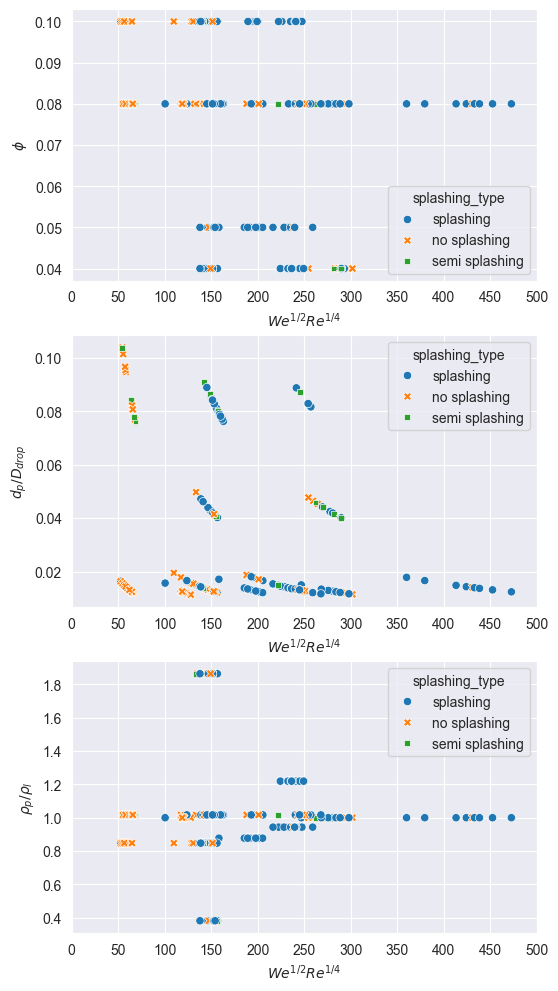

In [15]:
fig, (ax_volume_fraction, ax_diam_ratio, ax_density_ratio) = plt.subplots(3, 1, figsize=(6,12))
sns.scatterplot(data=df, x='We_Re', y='volume_fraction', hue='splashing_type', style='splashing_type', ax=ax_volume_fraction)
sns.scatterplot(data=df, x='We_Re', y='particle_droplet_diameter_ratio', hue='splashing_type', style='splashing_type', ax=ax_diam_ratio)
sns.scatterplot(data=df, x='We_Re', y='particle_liquid_density_ratio', hue='splashing_type', style='splashing_type', ax=ax_density_ratio)

axes = (ax_volume_fraction, ax_diam_ratio, ax_density_ratio)

for ax in axes:
    ax.set_xticks(list(np.arange(0, 510, 50)));
    ax.set_xlabel('$We^{1/2} Re^{1/4}$')

ax_volume_fraction.set_ylabel('$\phi$')
ax_diam_ratio.set_ylabel('$d_p/D_{drop}$')
ax_density_ratio.set_ylabel('$\\rho_{p}/\\rho_{l}$');

**Note:** volume_fraction plot is incorrect, since values 0.04 and 0.08 same as 0.05 and 0.10 respectively.

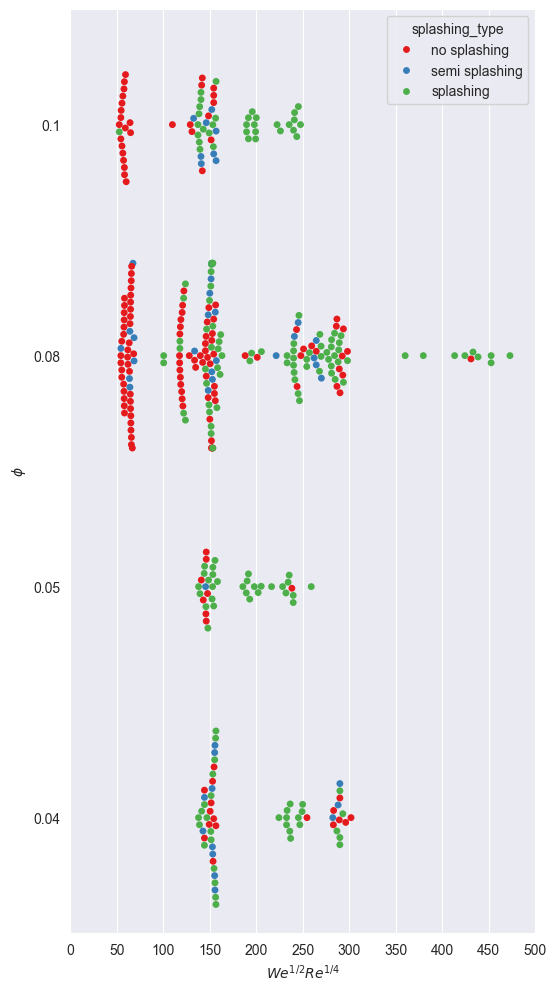

In [16]:
sns.color_palette('Set2')

fig, ax_volume_fraction_swarm = plt.subplots(figsize=(6,12))
sns.swarmplot(data=df, x='We_Re', y='volume_fraction', hue='splashing_type', # style='splashing_type', 
              ax=ax_volume_fraction_swarm, orient='h', size=4.95, order=[0.1, 0.08, 0.05, 0.04],
              hue_order=['no splashing', 'semi splashing', 'splashing'],
              palette='Set1'
            )


axes = (ax_volume_fraction_swarm, )

for ax in axes:
    ax.set_xticks(list(np.arange(0, 510, 50)));
    ax.set_xlabel('$We^{1/2} Re^{1/4}$')

ax_volume_fraction_swarm.set_ylabel('$\phi$');

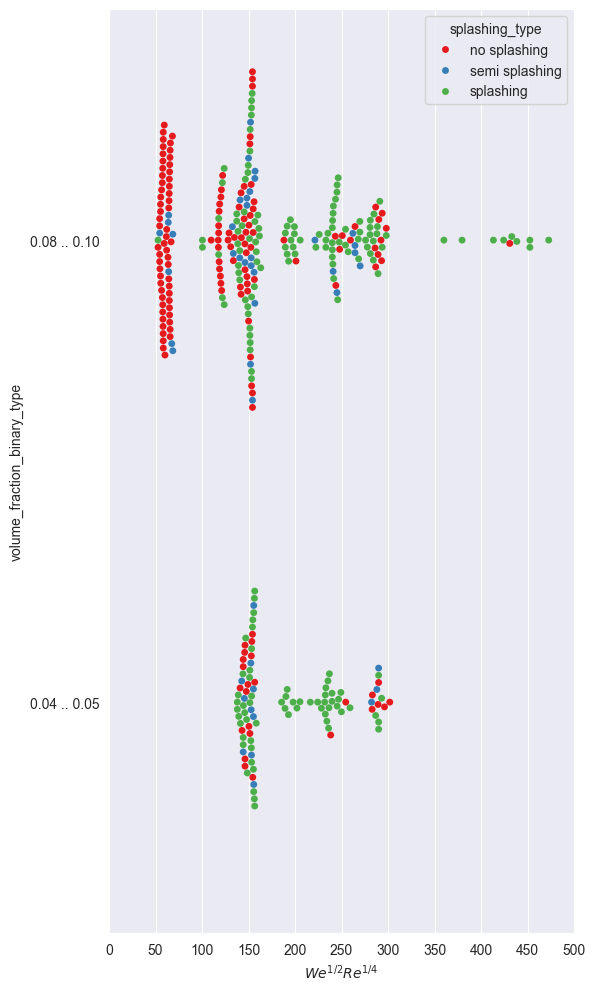

In [22]:
sns.color_palette('Set2')

fig, ax_volume_fraction_binary_swarm = plt.subplots(figsize=(6,12))
sns.swarmplot(data=df, x='We_Re', y='volume_fraction_binary_type', hue='splashing_type', # style='splashing_type', 
              ax=ax_volume_fraction_binary_swarm, orient='h', size=4.95, order=['0.08 .. 0.10', '0.04 .. 0.05'],
              hue_order=['no splashing', 'semi splashing', 'splashing'],
              palette='Set1'
            )


axes = (ax_volume_fraction_binary_swarm, )

for ax in axes:
    ax.set_xticks(list(np.arange(0, 510, 50)));
    ax.set_xlabel('$We^{1/2} Re^{1/4}$')

ax_volume_fraction_swarm.set_ylabel('$\phi$');

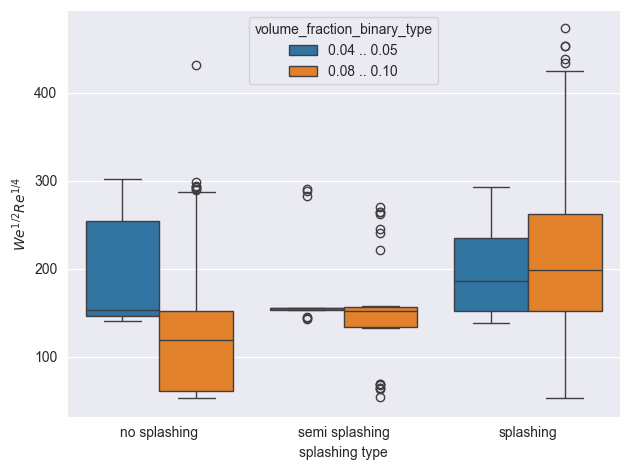

In [47]:
fig, ax = plt.subplots()
sns.boxplot(
    data=df, 
    x='splashing_type', y='We_Re', 
    order=['no splashing', 'semi splashing', 'splashing'], 
    hue='volume_fraction_binary_type',
    hue_order=['0.04 .. 0.05', '0.08 .. 0.10'],
    # flierprops={"marker": "x"},
    ax=ax
)
ax.set_ylabel('$We^{1/2} Re^{1/4}$')
ax.set_xlabel('splashing type');
fig.tight_layout()

Difficult to interpret this plot

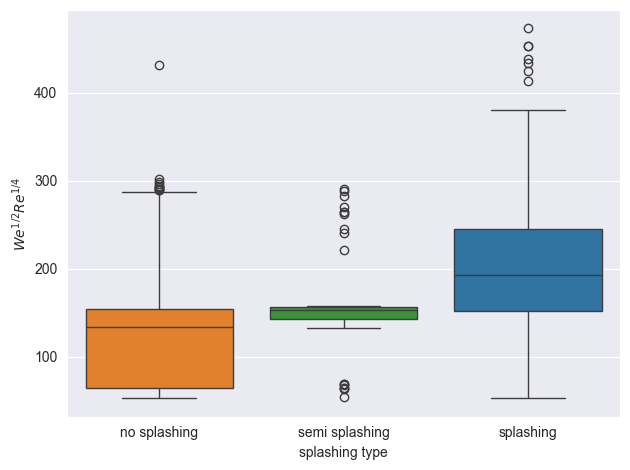

In [34]:
fig, ax = plt.subplots()
sns.boxplot(
    data=df, 
    x='splashing_type', y='We_Re', 
    order=['no splashing', 'semi splashing', 'splashing'], 
    hue='splashing_type',
    # flierprops={"marker": "x"},
    ax=ax
)
ax.set_ylabel('$We^{1/2} Re^{1/4}$')
ax.set_xlabel('splashing type');
fig.tight_layout()

### Check outliers


In [54]:

def get_outliers(series:pd.Series):
    Q1 = series.quantile(0.25)
    Q3 = series.quantile(0.75)
    median = series.median()
    
    IQR = Q3 - Q1
    
    outliers_tuple = (Q1 - 1.5*IQR, Q3 + 1.5*IQR)
    
    return outliers_tuple

We_Re_high_outlier = get_outliers(df[df['splashing'] == 0]['We_Re'])[1]
print(f'We_Re high outlier boundary: {We_Re_high_outlier:.2f}')
df[(df['splashing'] == 0) & (df['We_Re'] >= We_Re_high_outlier)]

We_Re high outlier boundary: 287.43


,test,wettability,roughness,liquid_density,surface_tension,viscosity,particle_mean_diameter,particle_density,volume_fraction,droplet_diameter,...,We,We_Re,net_impact,splashing,breaking_up,rebound,splashing_type,volume_fraction_binary_type,rebound_type,breaking_up_type
73,94,lyophilic,0.10,1000,0.0732,0.00104,0.000041,1000.0,0.04,0.003530,...,756.666109,296.205123,1,0,0,0,no splashing,0.04 .. 0.05,no,no
74,95,lyophilic,0.10,1000,0.0732,0.00104,0.000041,1000.0,0.04,0.003620,...,775.957880,301.851240,1,0,0,0,no splashing,0.04 .. 0.05,no,no
97,120,neutral,0.04,1000,0.0732,0.00104,0.000138,1000.0,0.04,0.003420,...,733.087279,289.255160,1,0,0,0,no splashing,0.04 .. 0.05,no,no
98,121,neutral,0.04,1000,0.0732,0.00104,0.000138,1000.0,0.04,0.003430,...,735.230809,289.889260,1,0,0,0,no splashing,0.04 .. 0.05,no,no
175,198,neutral,0.04,1000,0.0732,0.00104,0.000041,1000.0,0.08,0.003490,...,748.091989,293.684216,1,0,0,0,no splashing,0.08 .. 0.10,no,no
244,267,neutral,0.04,1000,0.0732,0.00104,0.000041,1000.0,0.08,0.003470,...,743.804929,292.421057,1,0,0,0,no splashing,0.08 .. 0.10,no,no
246,269,lyophilic,0.10,1000,0.0732,0.00104,0.000041,1000.0,0.08,0.003420,...,733.087279,289.255160,1,0,0,0,no splashing,0.08 .. 0.10,no,no
264,288,neutral,0.04,1000,0.0732,0.00104,0.000041,1000.0,0.08,0.003560,...,763.096699,298.091117,1,0,0,0,no splashing,0.08 .. 0.10,no,no
267,291,neutral,0.04,1000,0.0732,0.00104,0.000041,1000.0,0.08,0.003480,...,745.948459,293.052863,1,0,0,0,no splashing,0.08 .. 0.10,no,no
269,293,lyophilic,0.10,1000,0.0732,0.00104,0.000041,1000.0,0.08,0.003432,...,735.766691,290.047713,1,0,0,0,no splashing,0.08 .. 0.10,no,no


Check these tests

Tests 94, 95, 198. They gave someking of pseudo-net impact: no detaching droplets, but spot includes some droplet "branches":

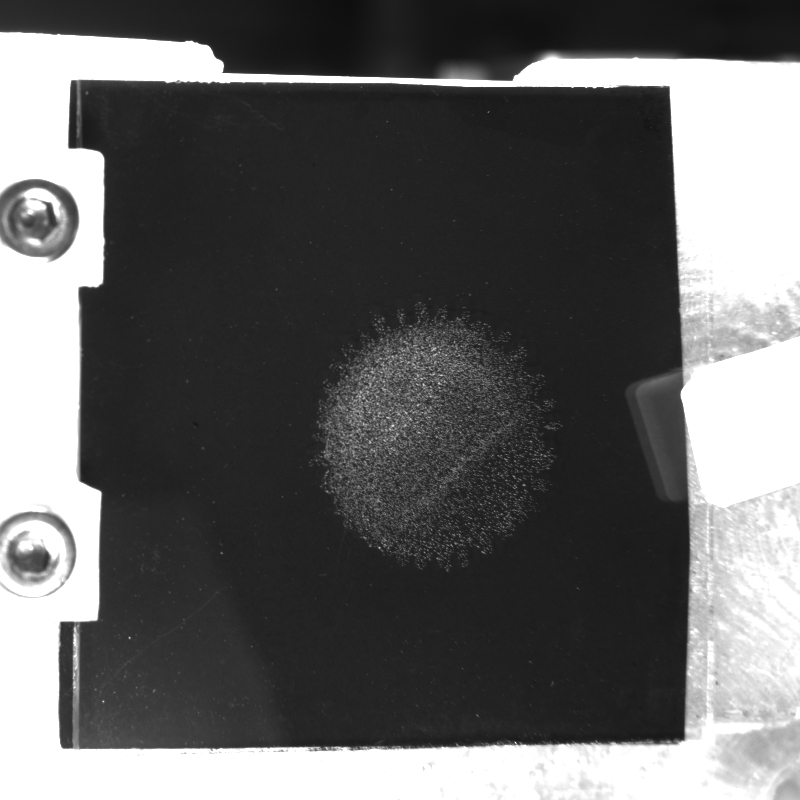

120, 365 - splashing cases!

121 - looks like splashing: tiny droplets + detaching during receding

267, 269, 288, 291, 293 - pseudo-net impact (like 94, but with inclination):

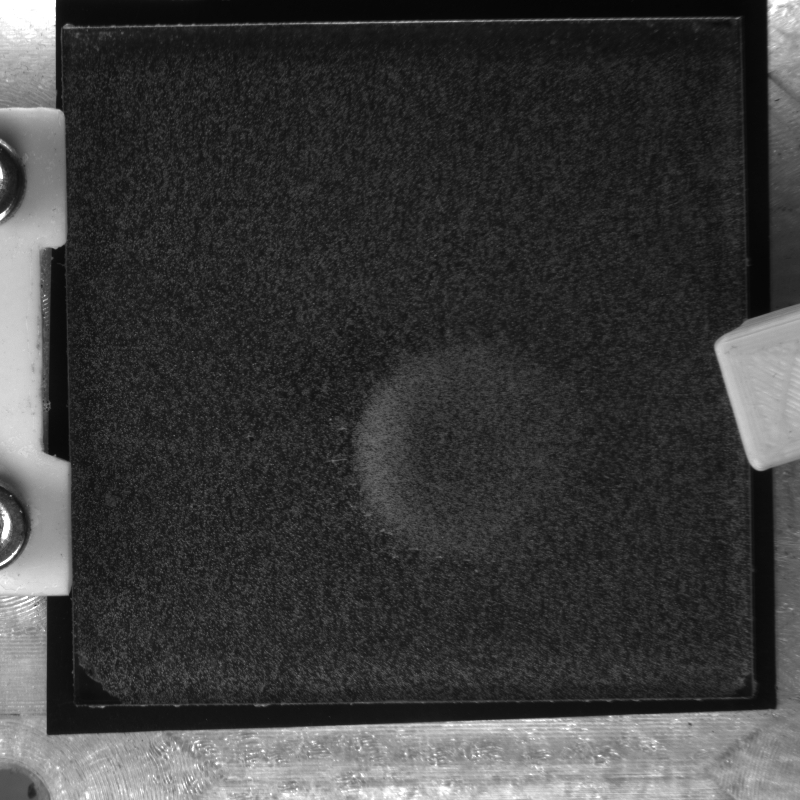

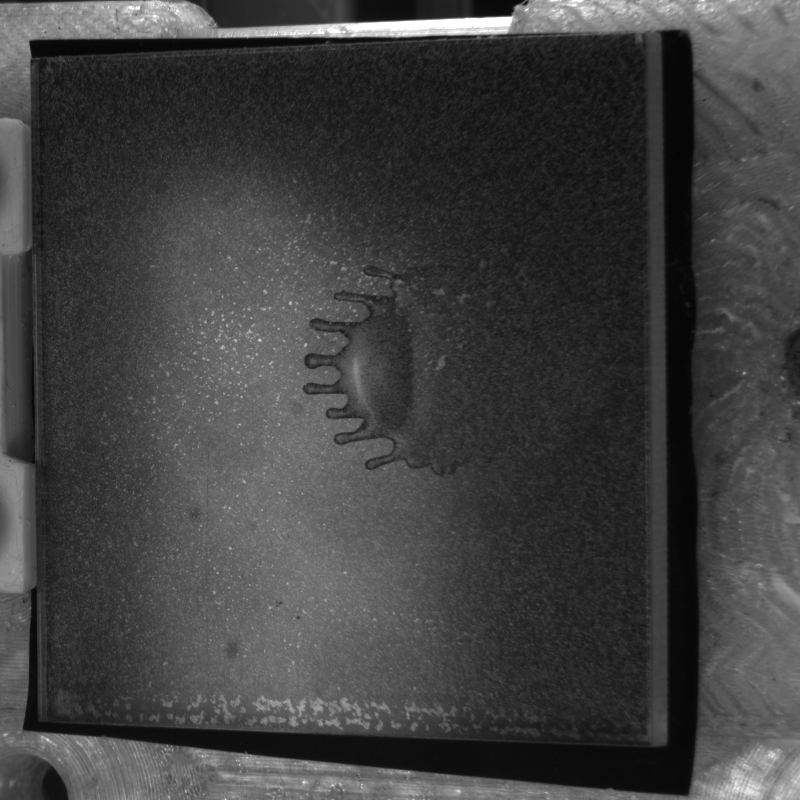

So, we can consider this cases as **semi-splashing (or even splashing)**

## Rebound

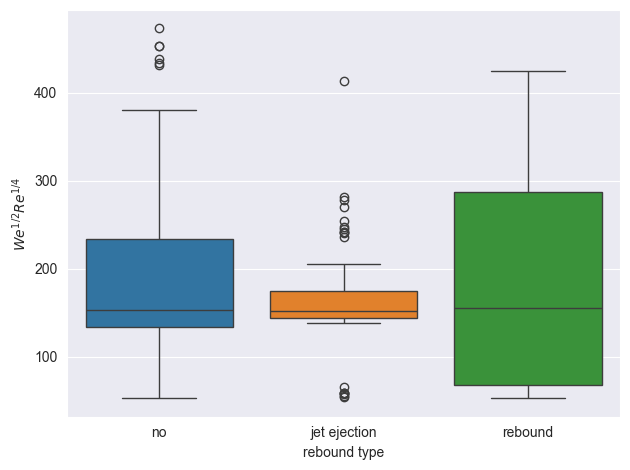

In [43]:
fig, ax = plt.subplots()
sns.boxplot(
    data=df, 
    x='rebound_type', y='We_Re',
    order=['no', 'jet ejection', 'rebound'],
    hue='rebound_type',
    ax=ax,
)

ax.set_ylabel('$We^{1/2} Re^{1/4}$')
ax.set_xlabel('rebound type');
fig.tight_layout()

No sufficient difference

## Breaking up

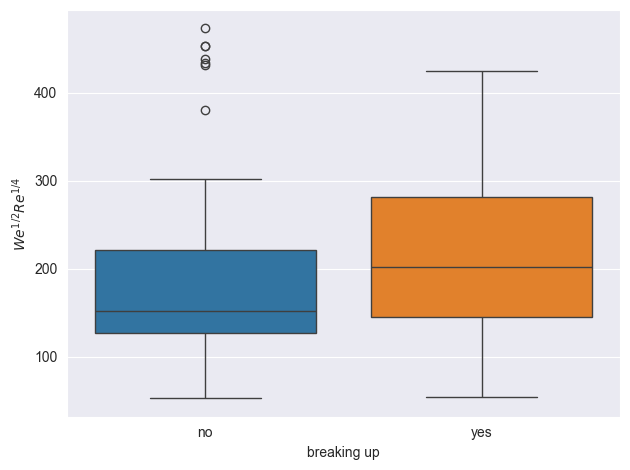

In [45]:
fig, ax = plt.subplots()
sns.boxplot(
    data=df, 
    x='breaking_up_type', y='We_Re', 
    hue='breaking_up_type',
    ax=ax,
)
ax.set_ylabel('$We^{1/2} Re^{1/4}$')
ax.set_xlabel('breaking up');
fig.tight_layout()

Let us consider duplicates. Do they have the same labels?

# ML-models predictions

TODO: plot ML-models contours

- **particle_droplet_diameter_ratio** = particle_mean_diameter / droplet_diameter
- **particle_liquid_density_ratio** = particle_density / liquid_density
- **volume_fraction**

in dependence on the **We_Re**

In [60]:
df[['We_Re', 'particle_droplet_diameter_ratio', 'particle_liquid_density_ratio', 'volume_fraction']].describe().T

,count,mean,std,min,25%,50%,75%,max
We_Re,372.0,171.483225,81.819240,52.684981,133.397611,152.920577,236.153834,472.780129
particle_droplet_diameter_ratio,372.0,0.026760,0.025510,0.011339,0.012604,0.013540,0.024635,0.103774
particle_liquid_density_ratio,372.0,0.994035,0.261595,0.381356,0.943396,1.000000,1.016949,1.864407
volume_fraction,372.0,0.073952,0.020020,0.040000,0.050000,0.080000,0.080000,0.100000
